# Exploratory Data Analysis

Loads all data sources, profiles their structure and quality, and produces
visualisations to build intuition before modelling.

**Sections**
1. Setup
2. Instruments
3. Portfolio Positions
4. Prices — Raw Quality Audit
5. Prices — Cleaning
6. Returns
7. Stress Scenarios

Portfolio risk characteristics (weighted vol contribution, correlation) are in [`portfolio_risk.ipynb`](portfolio_risk.ipynb).

## 1. Setup

In [1]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print("Working directory:", repo_root)

Working directory: /home/martin/python/risk-assessment


In [2]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

from data_loader import (
    clean_prices,
    load_instruments,
    load_positions,
    load_prices,
    load_scenarios,
)

DB_PATH = "data/reference.duckdb"

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Instruments

In [3]:
instruments = load_instruments()
print(f"Shape: {instruments.shape}")
instruments.dtypes

Shape: (18, 11)


instrument_id                   str
instrument_name                 str
asset_class                     str
sub_class                       str
sector                          str
currency                        str
country                         str
credit_rating                   str
maturity_date        datetime64[us]
coupon_rate                 float64
modified_duration           float64
dtype: object

In [4]:
instruments.head(10)

,instrument_id,instrument_name,asset_class,sub_class,sector,currency,country,credit_rating,maturity_date,coupon_rate,modified_duration
0,NESN,Nestle SA,EQUITY,SWISS_EQUITY,Consumer Staples,CHF,CH,NaN,NaT,NaN,NaN
1,NOVN,Novartis AG,EQUITY,SWISS_EQUITY,Healthcare,CHF,CH,NaN,NaT,NaN,NaN
2,ROG,Roche Holding AG,EQUITY,SWISS_EQUITY,Healthcare,CHF,CH,NaN,NaT,NaN,NaN
3,UBSG,UBS Group AG,EQUITY,SWISS_EQUITY,Financials,CHF,CH,NaN,NaT,NaN,NaN
4,ABBN,ABB Ltd,EQUITY,SWISS_EQUITY,Industrials,CHF,CH,NaN,NaT,NaN,NaN
5,SREN,Swiss Re AG,EQUITY,SWISS_EQUITY,Insurance,CHF,CH,NaN,NaT,NaN,NaN
6,SAN_FP,Sanofi SA,EQUITY,EUR_EQUITY,Healthcare,CHF,FR,NaN,NaT,NaN,NaN
7,SIE_GR,Siemens AG,EQUITY,EUR_EQUITY,Industrials,CHF,DE,NaN,NaT,NaN,NaN
8,ASML_NA,ASML Holding NV,EQUITY,EUR_EQUITY,Technology,CHF,NL,NaN,NaT,NaN,NaN
9,ALV_GR,Allianz SE,EQUITY,EUR_EQUITY,Insurance,CHF,DE,NaN,NaT,NaN,NaN


In [5]:
print("Null counts per column:")
display(instruments.isna().sum().rename("null_count").to_frame())

print("\nBreakdown by asset_class / sub_class:")
display(
    instruments.groupby(["asset_class", "sub_class"])
    .size()
    .rename("count")
    .reset_index()
)

Null counts per column:


,null_count
instrument_id,0
instrument_name,0
asset_class,0
sub_class,0
sector,5
currency,0
country,0
credit_rating,10
maturity_date,10
coupon_rate,10



Breakdown by asset_class / sub_class:


,asset_class,sub_class,count
0,CORP_BOND,CHF_CORP,3
1,EQUITY,EUR_EQUITY,4
2,EQUITY,SWISS_EQUITY,6
3,GOVT_BOND,CHF_GOVT,3
4,GOVT_BOND,EUR_GOVT,2


In [6]:
# Fixed-income instruments: ratings, coupons, and duration profile
fi = instruments[instruments["modified_duration"].notna()].copy()
print(f"Fixed-income instruments: {len(fi)}")
fi[["instrument_name", "sub_class", "credit_rating", "coupon_rate", "modified_duration"]].sort_values(
    "modified_duration", ascending=False
)

Fixed-income instruments: 8


,instrument_name,sub_class,credit_rating,coupon_rate,modified_duration
12,Swiss Confederation 10Y,CHF_GOVT,AAA,0.01,8.70
14,French OAT 7Y,EUR_GOVT,AA,0.02,6.20
16,Novartis Corp Bond 5.1Y,CHF_CORP,AA-,0.01,5.10
11,Swiss Confederation 5Y,CHF_GOVT,AAA,0.01,4.60
13,German Bund 5Y,EUR_GOVT,AAA,0.01,4.50
17,UBS Corp Bond 4.2Y,CHF_CORP,A+,0.02,4.20
15,Nestle Corp Bond 3.8Y,CHF_CORP,AA,0.01,3.80
10,Swiss Confederation 2Y,CHF_GOVT,AAA,0.01,1.90


## 3. Portfolio Positions

In [7]:
with duckdb.connect(DB_PATH, read_only=True) as con:
    portfolio_meta = con.execute("SELECT * FROM portfolio_meta").fetchdf()

portfolio_meta

,portfolio_id,portfolio_name,base_currency,total_nav,benchmark,inception_date,valuation_date
0,MAIN,Multi-Asset Fund,CHF,"500,000,000.00",Custom Composite (40% SPI / 60% SBI),2025-04-01,2026-03-18


In [86]:
positions = load_positions()
print(f"Shape:         {positions.shape}")
print(f"Snapshot date: {positions['snapshot_date'].unique()}")
print(f"Total weight:  {positions['weight'].sum():.6f}")
print(f"Total NAV:     CHF {positions['market_value_chf'].sum():,.0f}")

Shape:         (18, 16)
Snapshot date: <DatetimeArray>
['2026-03-18 00:00:00']
Length: 1, dtype: datetime64[us]
Total weight:  1.000000
Total NAV:     CHF 500,000,000


### 3.1 Exploring Positions History Table

`load_positions` returns one row per instrument — the most recent snapshot, selected with `QUALIFY ROW_NUMBER() OVER (PARTITION BY instrument_id ORDER BY snapshot_date DESC) = 1`. The cell below shows the raw history table. A comparison of SQL alternatives (window function vs scalar vs correlated subquery) is in [`sql_latest_snapshot.ipynb`](sql_latest_snapshot.ipynb).

In [87]:
# Inspect the raw positions_history table — multiple snapshots per instrument.
with duckdb.connect(DB_PATH, read_only=True) as con:
    history = con.execute(
        "SELECT instrument_id, snapshot_date, market_value_chf, weight "
        "FROM positions_history "
        "ORDER BY instrument_id, snapshot_date"
    ).fetchdf()

print(f"Total rows in positions_history: {len(history)}")
print(f"Distinct instruments:            {history['instrument_id'].nunique()}")
print(f"Distinct snapshot dates:         {sorted(history['snapshot_date'].unique())}")
history.head(12)

Total rows in positions_history: 90
Distinct instruments:            18
Distinct snapshot dates:         [Timestamp('2025-04-01 00:00:00'), Timestamp('2025-06-27 00:00:00'), Timestamp('2025-09-24 00:00:00'), Timestamp('2025-12-22 00:00:00'), Timestamp('2026-03-18 00:00:00')]


,instrument_id,snapshot_date,market_value_chf,weight
0,ABBN,2025-04-01,"15,689,558.44",0.03
1,ABBN,2025-06-27,"13,365,383.64",0.03
2,ABBN,2025-09-24,"13,734,477.35",0.03
3,ABBN,2025-12-22,"13,823,265.69",0.03
4,ABBN,2026-03-18,"15,000,000.00",0.03
5,ALV_GR,2025-04-01,"9,460,513.11",0.02
6,ALV_GR,2025-06-27,"9,949,096.97",0.02
7,ALV_GR,2025-09-24,"9,511,696.48",0.02
8,ALV_GR,2025-12-22,"10,076,495.62",0.02
9,ALV_GR,2026-03-18,"10,000,000.00",0.02


### 3.5 Position Overview

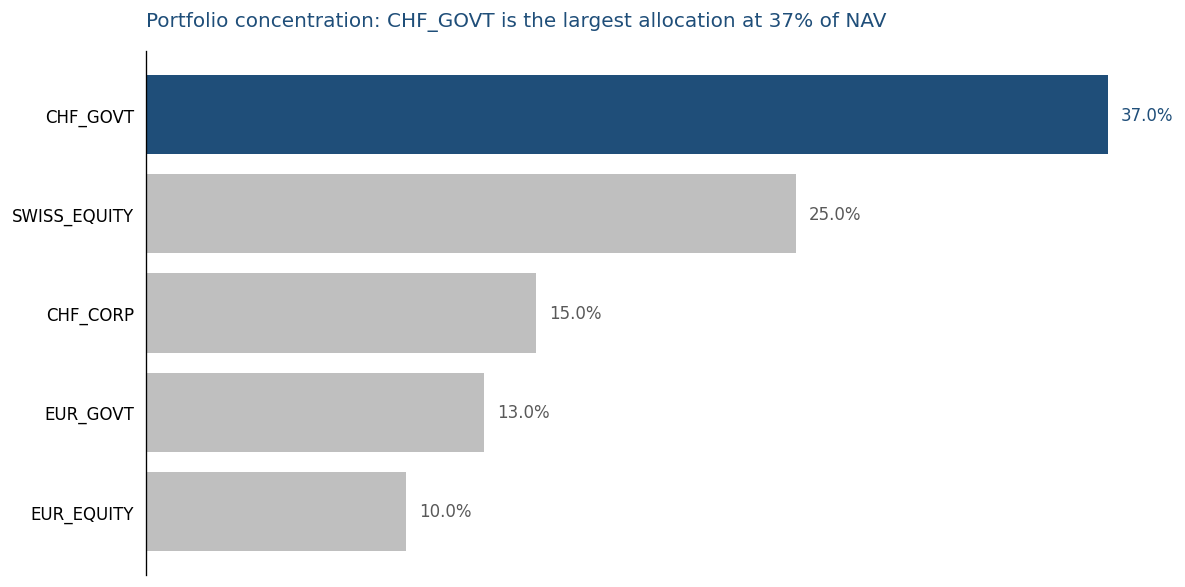

In [88]:
# Compute allocation sorted largest-first (Knaflic: largest at top)
alloc = (
    positions.groupby("sub_class")["market_value_chf"].sum().sort_values(ascending=True)
)  # ascending → largest appears at TOP in horizontal bar

total_nav = alloc.sum()
alloc_pct = alloc / total_nav * 100

# Single colour for non-emphasised bars, accent colour for the largest
colors = ["#BFBFBF"] * len(alloc_pct)
colors[-1] = "#1F4E79"  # emphasise the largest sub-class

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(alloc_pct.index, alloc_pct.values, color=colors)

# Data labels at the end of each bar — no need for a separate axis
for i, (bar, pct) in enumerate(zip(bars, alloc_pct.values, strict=True)):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        fontsize=10,
        color="#1F4E79" if i == len(alloc_pct) - 1 else "#595959",
    )

# Title as takeaway sentence
ax.set_title(
    f"Portfolio concentration: {alloc_pct.index[-1]} is the largest allocation at "
    f"{alloc_pct.iloc[-1]:.0f}% of NAV",
    loc="left",
    fontsize=12,
    color="#1F4E79",
    pad=15,
)

# Strip unnecessary elements
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(
    axis="x", which="both", bottom=False, labelbottom=False
)  # bar labels replace x-axis
ax.tick_params(axis="y", which="both", left=False)

plt.tight_layout()
plt.show()

In [89]:
print("Currency exposure (CHF market value):")
display(
    positions.groupby("currency")["market_value_chf"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

print("\nSector exposure (equities only):")
display(
    positions[positions["sector"].notna()]
    .groupby("sector")["market_value_chf"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

Currency exposure (CHF market value):


,market_value_chf
currency,
CHF,"500,000,000.00"



Sector exposure (equities only):


,market_value_chf
sector,
Healthcare,"92,500,000.00"
Consumer Staples,"60,000,000.00"
Financials,"37,500,000.00"
Industrials,"27,500,000.00"
Insurance,"20,000,000.00"
Technology,"12,500,000.00"


## 4. Prices — Raw Quality Audit

In [9]:
raw = load_prices()
print(f"Shape:       {raw.shape}")
print(f"Date range:  {raw['date'].min()} → {raw['date'].max()}")
print(f"Instruments: {raw['instrument_id'].nunique()}")
raw.tail(10)

Shape:       (4555, 3)
Date range:  2025-03-31 00:00:00 → 2026-03-18 00:00:00
Instruments: 18


,date,instrument_id,price
4545,2026-03-18,NESN,90.74
4546,2026-03-18,NESN_CORP,94.79
4547,2026-03-18,NOVN,62.37
4548,2026-03-18,NOVN_CORP,95.39
4549,2026-03-18,ROG,194.71
4550,2026-03-18,SAN_FP,108.73
4551,2026-03-18,SIE_GR,155.10
4552,2026-03-18,SREN,82.22
4553,2026-03-18,UBSG,17.70
4554,2026-03-18,UBSG_CORP,103.17


In [91]:
# Missing values per instrument
nan_by_instrument = (
    raw[raw["price"].isna()]
    .groupby("instrument_id")
    .size()
    .rename("nan_count")
    .sort_values(ascending=False)
)
print(f"Total NaN prices: {nan_by_instrument.sum()}")
display(nan_by_instrument.to_frame())

# Duplicate rows
dups = raw[raw.duplicated(subset=["date", "instrument_id"], keep=False)]
print(f"\nDuplicate rows: {len(dups)}")
display(dups.sort_values(["instrument_id", "date"]).head(8))

# Outlier scan: flag prices > 4x or < 0.25x the local rolling median
raw_sorted = raw.dropna().sort_values(["instrument_id", "date"])
rolling_med = raw_sorted.groupby("instrument_id")["price"].transform(
    lambda s: s.rolling(5, center=True, min_periods=1).median()
)
ratio = raw_sorted["price"] / rolling_med
outliers = raw_sorted[(ratio > 4) | (ratio < 0.25)].copy()
outliers["ratio_to_median"] = ratio[outliers.index].round(2)
print(f"\nSuspected outliers: {len(outliers)}")
display(outliers)

Total NaN prices: 2


,nan_count
instrument_id,
NESN,2



Duplicate rows: 2


,date,instrument_id,price
586,2025-05-14,NOVN,83.12
587,2025-05-14,NOVN,83.28



Suspected outliers: 1


,date,instrument_id,price,ratio_to_median
935,2025-06-10,UBSG,142.45,5.09


## 5. Prices — Cleaning

In [92]:
clean = clean_prices(raw)
print(f"Raw shape:            {raw.shape}")
print(f"Clean shape:          {clean.shape}")
print(f"NaNs remaining:       {clean['price'].isna().sum()}")
print(f"Duplicates remaining: {clean.duplicated(subset=['date', 'instrument_id']).sum()}")

# Latest clean price per instrument
latest = (
    clean.sort_values("date")
    .groupby("instrument_id", as_index=False)
    .last()
    .rename(columns={"price": "latest_price", "date": "latest_date"})
    .merge(instruments[["instrument_id", "sub_class"]], on="instrument_id")
    .sort_values(["sub_class", "instrument_id"])
    .reset_index(drop=True)
)
latest

Raw shape:            (4555, 3)
Clean shape:          (4554, 3)
NaNs remaining:       0
Duplicates remaining: 0


,instrument_id,latest_date,latest_price,sub_class
0,NESN_CORP,2026-03-18,94.79,CHF_CORP
1,NOVN_CORP,2026-03-18,95.39,CHF_CORP
2,UBSG_CORP,2026-03-18,103.17,CHF_CORP
3,CHGOV_10Y,2026-03-18,105.23,CHF_GOVT
4,CHGOV_2Y,2026-03-18,101.44,CHF_GOVT
5,CHGOV_5Y,2026-03-18,105.59,CHF_GOVT
6,ALV_GR,2026-03-18,200.29,EUR_EQUITY
7,ASML_NA,2026-03-18,377.92,EUR_EQUITY
8,SAN_FP,2026-03-18,108.73,EUR_EQUITY
9,SIE_GR,2026-03-18,155.10,EUR_EQUITY


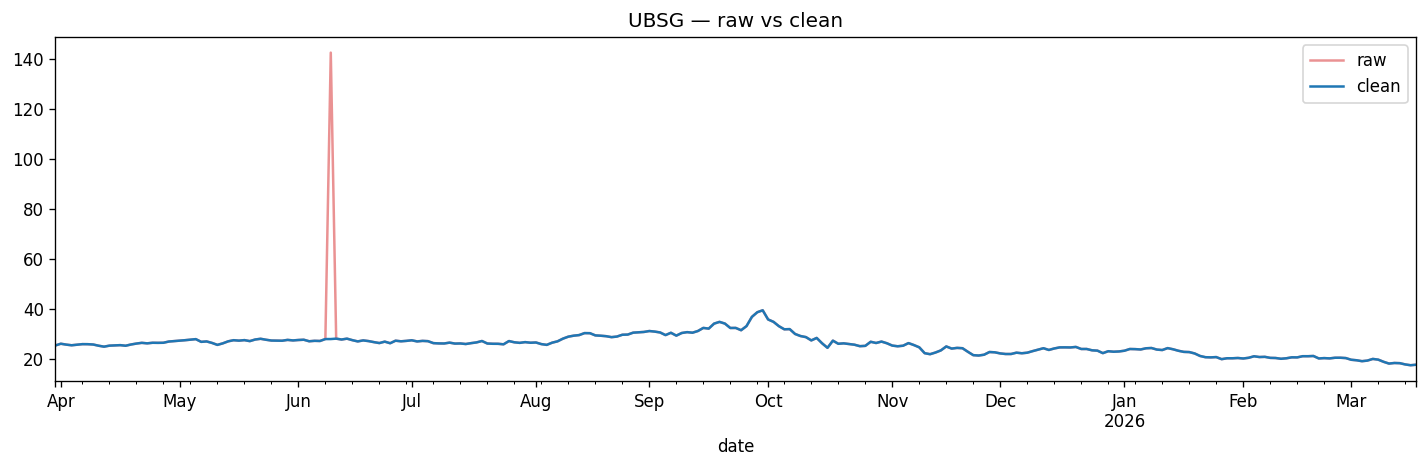

In [93]:
if len(outliers) > 0:
    outlier_ids = outliers["instrument_id"].unique()
    fig, axes = plt.subplots(len(outlier_ids), 1, figsize=(12, 4 * len(outlier_ids)), squeeze=False)
    for ax, iid in zip(axes[:, 0], outlier_ids, strict=True):
        raw_s   = raw[raw["instrument_id"] == iid].set_index("date")["price"]
        clean_s = clean[clean["instrument_id"] == iid].set_index("date")["price"]
        raw_s.plot(ax=ax, alpha=0.5, label="raw", color="tab:red")
        clean_s.plot(ax=ax, label="clean", color="tab:blue")
        ax.set_title(f"{iid} — raw vs clean")
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No outliers detected in raw prices.")

## 6. Returns

In [94]:
prices_wide = clean.pivot(index="date", columns="instrument_id", values="price").sort_index()
returns = prices_wide.pct_change().dropna(how="all")

print(f"Returns shape: {returns.shape}  ({returns.index.min()} → {returns.index.max()})")
returns.describe().T.sort_values("std", ascending=False).head(10)

Returns shape: (252, 18)  (2025-04-01 00:00:00 → 2026-03-18 00:00:00)


,count,mean,std,min,25%,50%,75%,max
instrument_id,,,,,,,,
ASML_NA,252.00,-0.00,0.03,-0.13,-0.02,-0.00,0.02,0.15
UBSG,252.00,-0.00,0.03,-0.09,-0.01,-0.00,0.01,0.12
SIE_GR,252.00,-0.00,0.02,-0.09,-0.01,-0.00,0.01,0.13
SREN,252.00,-0.00,0.02,-0.10,-0.01,-0.00,0.01,0.12
ALV_GR,252.00,-0.00,0.02,-0.09,-0.01,0.00,0.01,0.10
ABBN,252.00,-0.00,0.02,-0.12,-0.01,-0.00,0.01,0.10
SAN_FP,252.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.07
ROG,252.00,-0.00,0.02,-0.08,-0.01,-0.00,0.01,0.09
NOVN,252.00,-0.00,0.02,-0.08,-0.01,-0.00,0.01,0.10


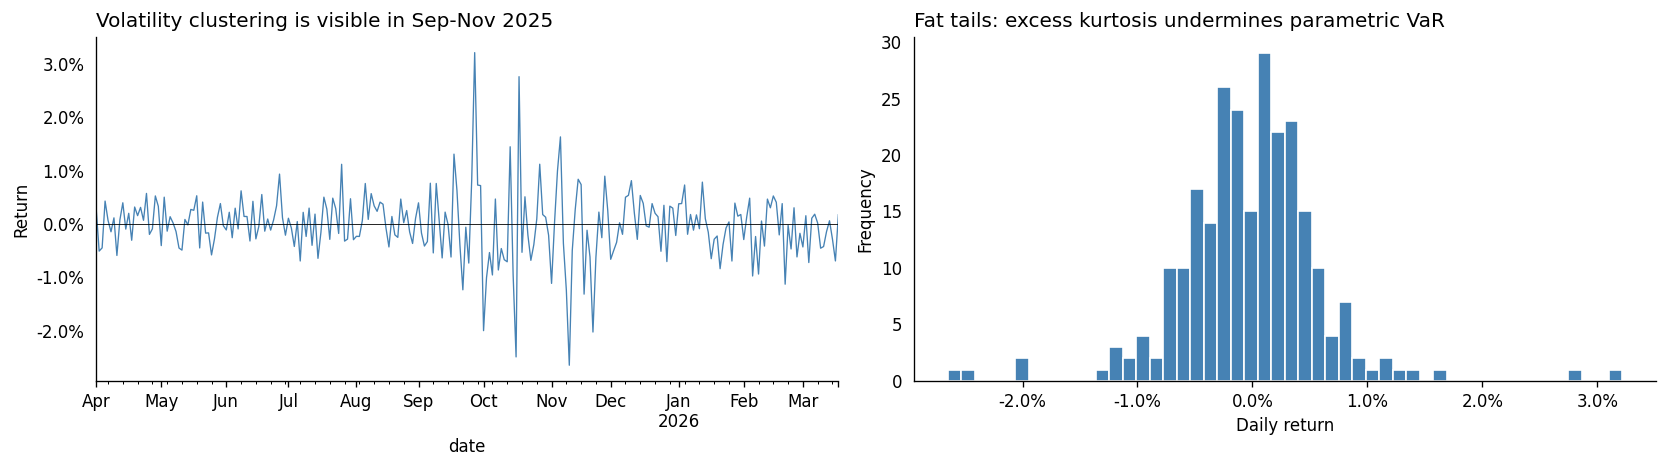

Annualized vol:  9.92%
Skewness:        0.185
Excess kurtosis: 5.936


In [95]:
weights = positions.set_index("instrument_id")["weight"]
common = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

port_returns.plot(ax=axes[0], color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Volatility clustering is visible in Sep-Nov 2025", loc="left")
axes[0].set_ylabel("Return")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
axes[0].tick_params(axis="y", left=False)
axes[0].spines[["top", "right"]].set_visible(False)

port_returns.plot.hist(ax=axes[1], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Fat tails: excess kurtosis undermines parametric VaR", loc="left")
axes[1].set_xlabel("Daily return")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
axes[1].tick_params(axis="y", left=False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Annualized vol:  {port_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness:        {port_returns.skew():.3f}")
print(f"Excess kurtosis: {port_returns.kurt():.3f}")

## 7. Stress Scenarios

Shape: (54, 5)  |  Distinct scenarios: 3


,,instruments_shocked
scenario_id,scenario_name,
EQUITY_CRASH,Global Equity Market Crash,18
EU_SOVEREIGN_SPREAD,European Sovereign Debt Stress,18
SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),18


,scenario_id,scenario_name,instrument_id,shock_return,description
0,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),NESN,-0.05,The SNB raises rates by 100bp unexpectedly to ...
1,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),NOVN,-0.05,The SNB raises rates by 100bp unexpectedly to ...
2,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ROG,-0.05,The SNB raises rates by 100bp unexpectedly to ...
3,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),UBSG,-0.10,The SNB raises rates by 100bp unexpectedly to ...
4,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ABBN,-0.06,The SNB raises rates by 100bp unexpectedly to ...
5,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),SREN,-0.09,The SNB raises rates by 100bp unexpectedly to ...
6,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),SAN_FP,-0.03,The SNB raises rates by 100bp unexpectedly to ...
7,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),SIE_GR,-0.04,The SNB raises rates by 100bp unexpectedly to ...
8,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ASML_NA,-0.07,The SNB raises rates by 100bp unexpectedly to ...
9,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ALV_GR,-0.08,The SNB raises rates by 100bp unexpectedly to ...


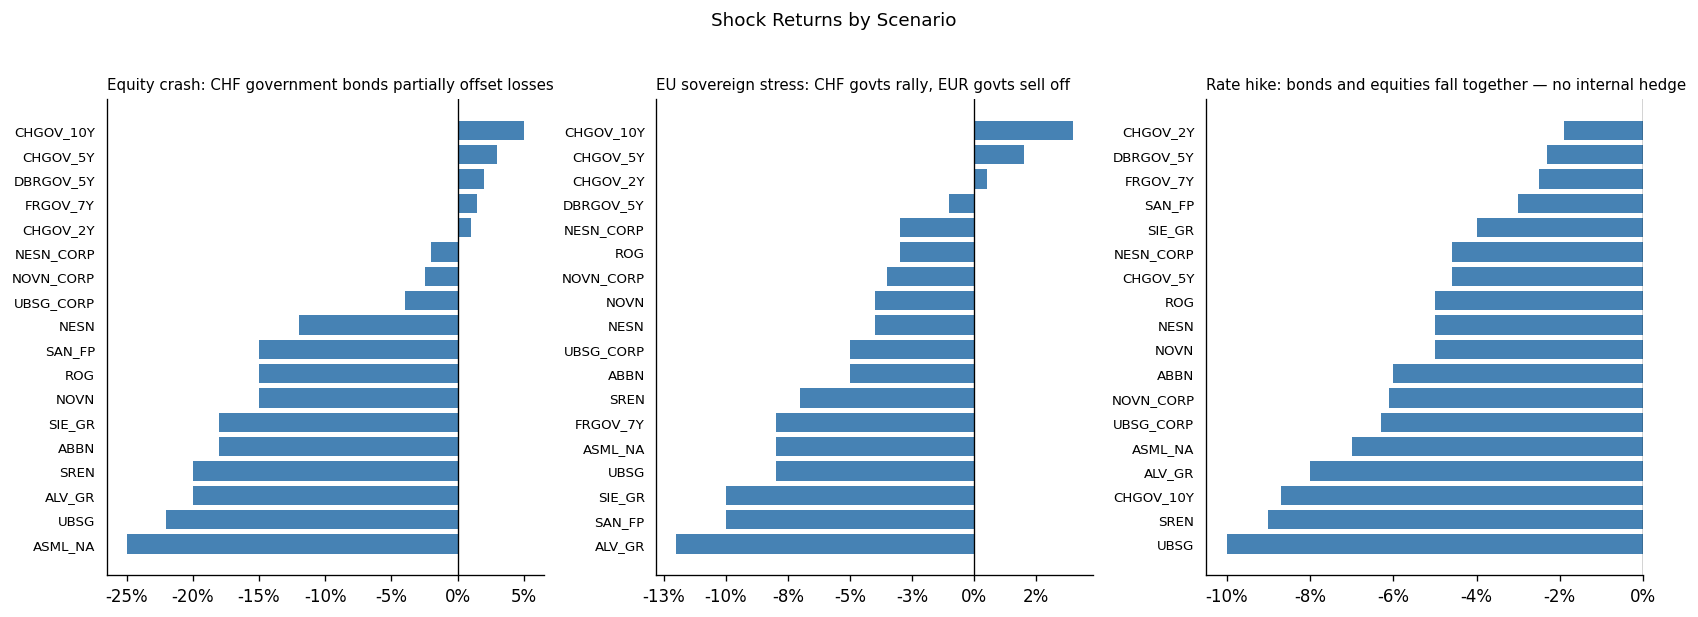

In [96]:
scenarios = load_scenarios()
print(f"Shape: {scenarios.shape}  |  Distinct scenarios: {scenarios['scenario_id'].nunique()}")
display(
    scenarios.groupby(["scenario_id", "scenario_name"])
    .size()
    .rename("instruments_shocked")
    .to_frame()
)
display(scenarios.head(15))

SCENARIO_TITLES = {
    "SNB_RATE_SHOCK":      "Rate hike: bonds and equities fall together — no internal hedge",
    "EU_SOVEREIGN_SPREAD": "EU sovereign stress: CHF govts rally, EUR govts sell off",
    "EQUITY_CRASH":        "Equity crash: CHF government bonds partially offset losses",
}

n_scenarios = scenarios["scenario_id"].nunique()
fig, axes = plt.subplots(1, n_scenarios, figsize=(14, 5), squeeze=False)

pct_formatter = FuncFormatter(lambda x, _: f"{x:.0%}")
for ax, (sid, grp) in zip(axes[0], scenarios.groupby("scenario_id"), strict=True):
    grp_sorted = grp.sort_values("shock_return")
    ax.barh(grp_sorted["instrument_id"], grp_sorted["shock_return"], color="steelblue")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(pct_formatter)
    ax.set_title(SCENARIO_TITLES.get(str(sid), str(grp["scenario_name"].iloc[0])), fontsize=9, loc="left")
    ax.tick_params(axis="y", labelsize=8, left=False)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Shock Returns by Scenario", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()